<a href="https://colab.research.google.com/github/rathoreved/Algorithm-Lab/blob/main/Lab_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Travelling Salesman Problem using Dynamic Programming.
Problem Description:
Given a set of cities and distances, find the shortest possible route that visits each city once and returns to the starting city.

#Theory
TSP uses dynamic programming with bit masking. Store results of visited subsets to reduce repeated work.

## Algorithm
1. Start from source city
2. Mark visited cities using bit mask
3. Try all unvisited cities
4. Choose minimum cost path
5. Return to source city

In [18]:
def tsp(graph):
    n = len(graph)
    dp = [[-1]*(1<<n) for _ in range(n)]

    def visit(city, mask):
        if mask == (1<<n) - 1:
            return graph[city][0]

        if dp[city][mask] != -1:
            return dp[city][mask]

        ans = float('inf')

        for next_city in range(n):
            if mask & (1<<next_city) == 0:
                new_cost = graph[city][next_city] + visit(next_city, mask | (1<<next_city))
                if new_cost < ans:
                    ans = new_cost

        dp[city][mask] = ans
        return ans

    return visit(0, 1)


In [19]:
graph = [
[0, 10, 15, 20],
[10, 0, 35, 25],
[15, 35, 0, 30],
[20, 25, 30, 0]
]

print("Minimum travelling cost:", tsp(graph))

Minimum travelling cost: 80


# Exercise
1. Print path of cities visited
2. Take graph input from user
3. Test with different number of cities

Enter number of cities: 4
Enter adjacency matrix (space separated):
0 10 15 20
10 0 35 25
15 35 0 30
20 25 30 0
Minimum cost: 80
Path: 0 -> 1 -> 3 -> 2 -> 0
Minimum travelling cost: 80
Path: 0 -> 1 -> 3 -> 2 -> 0


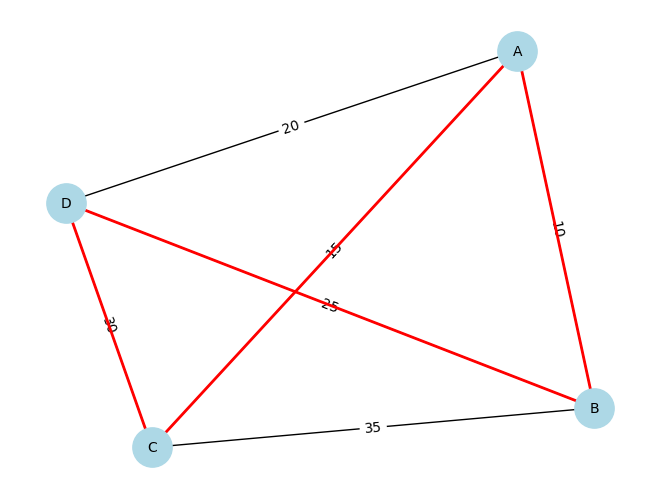

In [12]:
import sys


def tsp(graph, n):
    dp = [[None] * n for _ in range(1 << n)]
    parent = [[-1] * n for _ in range(1 << n)]

    def solve(mask, pos):
        if mask == (1 << n) - 1:
            return graph[pos][0]

        if dp[mask][pos] is not None:
            return dp[mask][pos]

        ans = sys.maxsize
        for city in range(n):
            if mask & (1 << city) == 0:
                new_cost = graph[pos][city] + solve(mask | (1 << city), city)
                if new_cost < ans:
                    ans = new_cost
                    parent[mask][pos] = city
        dp[mask][pos] = ans
        return ans

    min_cost = solve(1, 0)


    mask, pos = 1, 0
    path = [0]
    while True:
        next_city = parent[mask][pos]
        if next_city == -1:
            break
        path.append(next_city)
        mask |= (1 << next_city)
        pos = next_city
    path.append(0)

    return min_cost, path



if __name__ == "__main__":
    n = int(input("Enter number of cities: "))
    print("Enter adjacency matrix (space separated):")
    graph = []
    for _ in range(n):
        row = list(map(int, input().split()))
        graph.append(row)

    min_cost, path = tsp(graph, n)
    print("Minimum cost:", min_cost)
    print("Path:", " -> ".join(map(str, path)))


